In [1]:
# Step 1: Install dependencies (Colab)
!pip -q install xgboost joblib seaborn scikit-learn pandas numpy matplotlib


In [2]:
# Step 2: Imports and reproducibility
import json
import random
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
)
from xgboost import XGBClassifier

SEED = 42
np.random.seed(SEED)
random.seed(SEED)

FEATURES = [
    "Age",
    "BMI",
    "EducationLevel",
    "MMSE",
    "FunctionalAssessment",
    "MemoryComplaints",
    "Forgetfulness",
]
TARGET = "Diagnosis"

print("Seed:", SEED)
print("Features:", FEATURES)


Seed: 42
Features: ['Age', 'BMI', 'EducationLevel', 'MMSE', 'FunctionalAssessment', 'MemoryComplaints', 'Forgetfulness']


In [3]:
# Step 3: Upload CSV file (button appears in Colab)
from google.colab import files

uploaded = files.upload()
if not uploaded:
    raise ValueError("No file uploaded. Please upload alzheimers_disease_data.csv")

csv_candidates = [name for name in uploaded.keys() if name.lower().endswith(".csv")]
if not csv_candidates:
    raise ValueError("Uploaded file is not CSV. Please upload a .csv file")

csv_path = csv_candidates[0]
print("Using CSV:", csv_path)


Saving alzheimers_disease_data.csv to alzheimers_disease_data.csv
Using CSV: alzheimers_disease_data.csv


In [4]:
# Step 4: Load dataset and validate schema
raw_df = pd.read_csv(csv_path)
print("Raw shape:", raw_df.shape)
print("Columns:", list(raw_df.columns))

required_cols = FEATURES + [TARGET]
missing_cols = [c for c in required_cols if c not in raw_df.columns]
if missing_cols:
    raise ValueError(f"Missing required columns: {missing_cols}")

print("All required columns are present.")
raw_df.head()


Raw shape: (2149, 35)
Columns: ['PatientID', 'Age', 'Gender', 'Ethnicity', 'EducationLevel', 'BMI', 'Smoking', 'AlcoholConsumption', 'PhysicalActivity', 'DietQuality', 'SleepQuality', 'FamilyHistoryAlzheimers', 'CardiovascularDisease', 'Diabetes', 'Depression', 'HeadInjury', 'Hypertension', 'SystolicBP', 'DiastolicBP', 'CholesterolTotal', 'CholesterolLDL', 'CholesterolHDL', 'CholesterolTriglycerides', 'MMSE', 'FunctionalAssessment', 'MemoryComplaints', 'BehavioralProblems', 'ADL', 'Confusion', 'Disorientation', 'PersonalityChanges', 'DifficultyCompletingTasks', 'Forgetfulness', 'Diagnosis', 'DoctorInCharge']
All required columns are present.


,PatientID,Age,Gender,Ethnicity,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,DietQuality,...,MemoryComplaints,BehavioralProblems,ADL,Confusion,Disorientation,PersonalityChanges,DifficultyCompletingTasks,Forgetfulness,Diagnosis,DoctorInCharge
0,4751,73,0,0,2,22.927749,0,13.297218,6.327112,1.347214,...,0,0,1.725883,0,0,0,1,0,0,XXXConfid
1,4752,89,0,0,0,26.827681,0,4.542524,7.619885,0.518767,...,0,0,2.592424,0,0,0,0,1,0,XXXConfid
2,4753,73,0,3,1,17.795882,0,19.555085,7.844988,1.826335,...,0,0,7.119548,0,1,0,1,0,0,XXXConfid
3,4754,74,1,0,1,33.800817,1,12.209266,8.428001,7.435604,...,0,1,6.481226,0,0,0,0,0,0,XXXConfid
4,4755,89,0,0,0,20.716974,0,18.454356,6.310461,0.795498,...,0,0,0.014691,0,0,1,1,0,0,XXXConfid


In [5]:
# Step 5: Cleaning and type enforcement
working_df = raw_df[required_cols].copy()
rows_before = len(working_df)

for col in required_cols:
    working_df[col] = pd.to_numeric(working_df[col], errors="coerce")

working_df = working_df.dropna(subset=required_cols)
working_df = working_df[working_df[TARGET].isin([0, 1])]
working_df[TARGET] = working_df[TARGET].astype(int)

rows_after = len(working_df)
print(f"Rows before cleaning: {rows_before}")
print(f"Rows after cleaning : {rows_after}")
print(f"Dropped rows        : {rows_before - rows_after}")

if rows_after == 0:
    raise ValueError("No usable rows after cleaning.")

print("Target distribution:")
print(working_df[TARGET].value_counts(dropna=False))

X = working_df[FEATURES].copy()
y = working_df[TARGET].copy()


Rows before cleaning: 2149
Rows after cleaning : 2149
Dropped rows        : 0
Target distribution:
Diagnosis
0    1389
1     760
Name: count, dtype: int64


In [6]:
# Step 6: Stratified split 80/10/10
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=SEED,
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=SEED,
)

print("Train:", X_train.shape, y_train.shape)
print("Val  :", X_val.shape, y_val.shape)
print("Test :", X_test.shape, y_test.shape)

for name, split_y in [("train", y_train), ("val", y_val), ("test", y_test)]:
    dist = split_y.value_counts(normalize=True).sort_index()
    print(f"{name} class distribution ->", dist.to_dict())


Train: (1719, 7) (1719,)
Val  : (215, 7) (215,)
Test : (215, 7) (215,)
train class distribution -> {0: 0.6463059918557301, 1: 0.35369400814426993}
val class distribution -> {0: 0.6465116279069767, 1: 0.35348837209302325}
test class distribution -> {0: 0.6465116279069767, 1: 0.35348837209302325}


In [7]:
# Step 7: Compute imbalance weight and majority baseline
neg_count = int((y_train == 0).sum())
pos_count = int((y_train == 1).sum())
scale_pos_weight = neg_count / max(pos_count, 1)
print("neg_count:", neg_count, "pos_count:", pos_count)
print("scale_pos_weight:", round(scale_pos_weight, 4))

majority_class = int(y_train.value_counts().idxmax())
baseline_pred = np.full_like(y_test, fill_value=majority_class)
baseline_acc = accuracy_score(y_test, baseline_pred)
print("Majority-class baseline accuracy on test:", round(baseline_acc, 4))


neg_count: 1111 pos_count: 608
scale_pos_weight: 1.8273
Majority-class baseline accuracy on test: 0.6465


In [8]:
# Step 8: XGBoost training with lightweight randomized search (ROC-AUC)
base_model = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=SEED,
    tree_method="hist",
    n_jobs=-1,
)

param_distributions = {
    "n_estimators": [200, 300, 400, 500],
    "max_depth": [3, 4, 5, 6],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.7, 0.8, 0.9, 1.0],
    "min_child_weight": [1, 3, 5, 7],
    "gamma": [0.0, 0.1, 0.3],
    "reg_alpha": [0.0, 0.01, 0.1, 1.0],
    "reg_lambda": [1.0, 1.5, 2.0, 3.0],
    "scale_pos_weight": [scale_pos_weight],
}

search = RandomizedSearchCV(
    estimator=base_model,
    param_distributions=param_distributions,
    n_iter=20,
    scoring="roc_auc",
    cv=3,
    verbose=1,
    random_state=SEED,
    n_jobs=-1,
    refit=True,
)

search.fit(X_train, y_train)
best_model = search.best_estimator_

print("Best CV ROC-AUC:", round(search.best_score_, 4))
print("Best params:")
print(search.best_params_)


Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best CV ROC-AUC: 0.8511
Best params:
{'subsample': 0.7, 'scale_pos_weight': 1.8273026315789473, 'reg_lambda': 3.0, 'reg_alpha': 0.01, 'n_estimators': 300, 'min_child_weight': 7, 'max_depth': 3, 'learning_rate': 0.01, 'gamma': 0.3, 'colsample_bytree': 0.9}


In [9]:
# Step 9: Validation metrics + best F1 threshold search
val_probs = best_model.predict_proba(X_val)[:, 1]
val_auc = roc_auc_score(y_val, val_probs)
val_pr_auc = average_precision_score(y_val, val_probs)

precisions, recalls, thresholds = precision_recall_curve(y_val, val_probs)
f1_scores = 2 * precisions * recalls / (precisions + recalls + 1e-12)

if len(thresholds) > 0:
    best_idx = int(np.nanargmax(f1_scores[:-1]))
    best_threshold = float(thresholds[best_idx])
else:
    best_threshold = 0.5

print("Validation ROC-AUC:", round(val_auc, 4))
print("Validation PR-AUC :", round(val_pr_auc, 4))
print("Best F1 threshold from validation:", round(best_threshold, 4))


Validation ROC-AUC: 0.8802
Validation PR-AUC : 0.806
Best F1 threshold from validation: 0.6478


In [10]:
# Step 10: Final fit on train+val, then evaluate on test
X_trainval = pd.concat([X_train, X_val], axis=0)
y_trainval = pd.concat([y_train, y_val], axis=0)

final_model = best_model
final_model.fit(X_trainval, y_trainval)

test_probs = final_model.predict_proba(X_test)[:, 1]
test_preds_default = (test_probs >= 0.5).astype(int)
test_preds_best_f1 = (test_probs >= best_threshold).astype(int)

def compute_metrics(y_true, y_pred, y_prob):
    return {
        "roc_auc": float(roc_auc_score(y_true, y_prob)),
        "pr_auc": float(average_precision_score(y_true, y_prob)),
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "precision": float(precision_score(y_true, y_pred, zero_division=0)),
        "recall": float(recall_score(y_true, y_pred, zero_division=0)),
        "f1": float(f1_score(y_true, y_pred, zero_division=0)),
    }

metrics_default = compute_metrics(y_test, test_preds_default, test_probs)
metrics_best_f1 = compute_metrics(y_test, test_preds_best_f1, test_probs)

print("Test metrics (threshold=0.5)")
for k, v in metrics_default.items():
    print(f"  {k}: {v:.4f}")

print("\nTest metrics (threshold=best val F1)")
for k, v in metrics_best_f1.items():
    print(f"  {k}: {v:.4f}")


Test metrics (threshold=0.5)
  roc_auc: 0.8553
  pr_auc: 0.7917
  accuracy: 0.7721
  precision: 0.6364
  recall: 0.8289
  f1: 0.7200

Test metrics (threshold=best val F1)
  roc_auc: 0.8553
  pr_auc: 0.7917
  accuracy: 0.7814
  precision: 0.6526
  recall: 0.8158
  f1: 0.7251


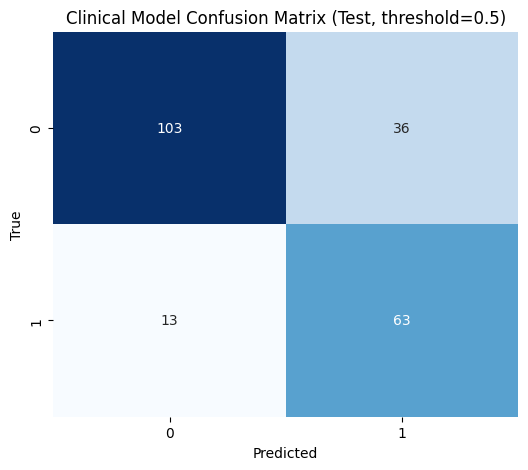

Classification report (threshold=0.5):
              precision    recall  f1-score   support

           0     0.8879    0.7410    0.8078       139
           1     0.6364    0.8289    0.7200        76

    accuracy                         0.7721       215
   macro avg     0.7621    0.7850    0.7639       215
weighted avg     0.7990    0.7721    0.7768       215



In [11]:
# Step 11: Confusion matrix + classification report (threshold=0.5)
cm = confusion_matrix(y_test, test_preds_default)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title("Clinical Model Confusion Matrix (Test, threshold=0.5)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

print("Classification report (threshold=0.5):")
print(classification_report(y_test, test_preds_default, digits=4, zero_division=0))


In [12]:
# Step 12: Save artifacts
artifact_dir = Path("clinical_artifacts")
artifact_dir.mkdir(parents=True, exist_ok=True)

model_path = artifact_dir / "clinical_xgb_model.joblib"
features_path = artifact_dir / "clinical_features.json"
metrics_path = artifact_dir / "clinical_model_metrics.json"
thresholds_path = artifact_dir / "clinical_thresholds.json"

joblib.dump(final_model, model_path)

features_payload = {
    "feature_order": FEATURES,
    "target": TARGET,
    "notes": "Maintain exact feature order during inference.",
}

metrics_payload = {
    "seed": SEED,
    "split": "stratified_80_10_10",
    "train_rows": int(len(X_train)),
    "val_rows": int(len(X_val)),
    "test_rows": int(len(X_test)),
    "class_balance_train": {
        "negative_0": int((y_train == 0).sum()),
        "positive_1": int((y_train == 1).sum()),
        "scale_pos_weight": float(scale_pos_weight),
    },
    "cv_best_score_roc_auc": float(search.best_score_),
    "best_params": search.best_params_,
    "validation": {
        "roc_auc": float(val_auc),
        "pr_auc": float(val_pr_auc),
        "best_f1_threshold": float(best_threshold),
    },
    "test_threshold_0_5": metrics_default,
    "test_threshold_best_f1": metrics_best_f1,
    "majority_baseline_accuracy_test": float(baseline_acc),
}

thresholds_payload = {
    "risk_mapping": {
        "low": "probability < 0.3",
        "medium": "0.3 <= probability <= 0.7",
        "high": "probability > 0.7",
    },
    "classification_threshold_default": 0.5,
    "classification_threshold_best_f1_on_validation": float(best_threshold),
}

features_path.write_text(json.dumps(features_payload, indent=2))
metrics_path.write_text(json.dumps(metrics_payload, indent=2))
thresholds_path.write_text(json.dumps(thresholds_payload, indent=2))

print("Saved artifacts:")
print("-", model_path)
print("-", features_path)
print("-", metrics_path)
print("-", thresholds_path)


Saved artifacts:
- clinical_artifacts/clinical_xgb_model.joblib
- clinical_artifacts/clinical_features.json
- clinical_artifacts/clinical_model_metrics.json
- clinical_artifacts/clinical_thresholds.json


In [13]:
# Step 13: Inference demo (app contract aligned)
def map_risk_band(prob):
    if prob < 0.3:
        return "low"
    if prob <= 0.7:
        return "medium"
    return "high"

sample = X_test.iloc[0].to_dict()
sample_df = pd.DataFrame([sample], columns=FEATURES)

probability = float(final_model.predict_proba(sample_df)[0, 1])
prediction = int(probability >= 0.5)
risk_band = map_risk_band(probability)

result = {
    "input": sample,
    "diagnosis_probability": probability,
    "predicted_label_threshold_0_5": prediction,
    "mapped_risk": risk_band,
}

print(json.dumps(result, indent=2))


{
  "input": {
    "Age": 70.0,
    "BMI": 37.079982995306096,
    "EducationLevel": 1.0,
    "MMSE": 4.520177677729981,
    "FunctionalAssessment": 3.748488867537242,
    "MemoryComplaints": 0.0,
    "Forgetfulness": 0.0
  },
  "diagnosis_probability": 0.7541202902793884,
  "predicted_label_threshold_0_5": 1,
  "mapped_risk": "high"
}


In [14]:
# Step 14 (Optional): Download artifacts from Colab
from google.colab import files

for p in [
    "clinical_artifacts/clinical_xgb_model.joblib",
    "clinical_artifacts/clinical_features.json",
    "clinical_artifacts/clinical_model_metrics.json",
    "clinical_artifacts/clinical_thresholds.json",
]:
    files.download(p)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>